In [1]:
'''
We recommended that Boyan try to emulate spectroscopic completeness by matching 
the Khostovan+2026 COSMOS spec-z compilation to Cardinal galaxies using redshift, 
magnitude, and then color matched by percentile (i.e., so a real galaxy with a 10th
percentile real g-r color would map to a simulated galaxy with a 10th percentile simulated 
g-r color---this should help mitigate the distribution shift between real colors and 
simulated colors)
'''

'\nWe recommended that Boyan try to emulate spectroscopic completeness by matching \nthe Khostovan+2026 COSMOS spec-z compilation to Cardinal galaxies using redshift, \nmagnitude, and then color matched by percentile (i.e., so a real galaxy with a 10th\npercentile real g-r color would map to a simulated galaxy with a 10th percentile simulated \ng-r color---this should help mitigate the distribution shift between real colors and \nsimulated colors)\n'

In [2]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math
import pyarrow as pa
import pyarrow.parquet as pq

/global/homes/b/boyanyin/.conda/envs/sompz/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
hdul = fits.open('Khostovan/specz_compilation_COSMOS_DR1.1_unique.fits')

data = hdul[1].data
header = hdul[0].header
#print(header)
print(data.names)

['Id_specz', 'Id_original', 'ra_original', 'dec_original', 'ra_corrected', 'dec_corrected', 'Priority', 'specz', 'flag', 'Confidence_level', 'survey', 'compilation_year', 'public_or_private', 'Id_COS20_Classic', 'ra_COS20_Classic', 'dec_COS20_Classic', 'Id_COS20_Farmer', 'ra_COS20_Farmer', 'dec_COS20_Farmer', 'Id_COSMOS25', 'ra_COSMOS25', 'dec_COSMOS25', 'Id_COSMOS15', 'ra_COSMOS15', 'dec_COSMOS15', 'Id_COSMOS09', 'ra_COSMOS09', 'dec_COSMOS09', 'photoz', 'photoz_type', 'GroupID', 'GroupSize']


## Check with Kohostovan paper

In [4]:
# Matching to paper listed numbers
#slightly smaller due to Sec 3.3. Mitigating Pair Galaxy Effects
print('A total of 266,284 unique sources make up the compilation, with 184,633 and 4338 sources having Qf = 3–4 and Qf = 13–14, respectively')
print('Tot unique source: ', np.shape(data['flag'])[0])
print('Qf = 3–4: ', np.sum((data['flag'] == 3) | (data['flag'] == 4)))
print('Qf = 13–14: ',np.sum((data['flag'] == 13) | (data['flag'] == 14)), '\n')
print('This corresponds to 133,916 unique sources (92% of all unique sources within COSMOS2020 coverage) with COSMOS2020 Classic photometry')
print('COSMOS2020 Classic: ', np.sum(data['Id_COS20_Classic']!= -999))

A total of 266,284 unique sources make up the compilation, with 184,633 and 4338 sources having Qf = 3–4 and Qf = 13–14, respectively
Tot unique source:  261975
Qf = 3–4:  183221
Qf = 13–14:  4328 

This corresponds to 133,916 unique sources (92% of all unique sources within COSMOS2020 coverage) with COSMOS2020 Classic photometry
COSMOS2020 Classic:  130065


In [5]:
#However, results shown
#below are restricted to SED fits for sources that have 𝑄 𝑓 = 3
#and 4, resulting in a total of 82,261 COSMOS2020 Classicmatched 0 < 𝑧 < 7.7 unique sources.
#Not right as the paper warn the star and AGN contamination of this selection

In [6]:
is_classic = (data['Id_COS20_Classic']!= -999)
goodz =  (data['flag'] == 3) | (data['flag'] == 4)
galaxy = data['photoz_type'] == 0

In [7]:
sel_classic = is_classic & goodz & galaxy

In [8]:
print(np.sum(sel_classic))
print(np.max(data['specz'][sel_classic]))
print(np.min(data['specz'][sel_classic]))

72182
7.677
-0.00013


In [9]:
is_farmer = (data['Id_COS20_Farmer']!= -999)
goodz =  (data['flag'] == 3) | (data['flag'] == 4)
galaxy = data['photoz_type'] == 0
sel_farmer = is_farmer & goodz & galaxy
print(np.sum(sel_farmer))

36719


In [10]:
spec_sample = pd.DataFrame(data[sel_classic])

In [11]:
## Matches are non-unique. Here I will only match to Classic
idx_multimatch = np.where(is_classic & is_farmer)[0]
print(idx_multimatch)
print(data['Id_COS20_Classic'][6601],  data['Id_COS20_Farmer'][6601])
print(data['ra_COS20_Classic'][6601],  data['ra_COS20_Farmer'][6601])
print(data['dec_COS20_Classic'][6601],  data['dec_COS20_Farmer'][6601])

[  6601   6887   6889 ... 121284 121297 121302]
135629 86094
149.90608416834624 149.90608301521897
1.5438157445575384 1.5437688087711101


## Match to COSMOS

In [12]:
import numpy as np
from astropy.table import Table
from astropy.io import fits

bands = ['CFHT_u', 'HSC_g', 'HSC_r', 'HSC_i', 'HSC_z', 'HSC_y',
         'UVISTA_Y', 'UVISTA_J', 'UVISTA_H', 'UVISTA_Ks']

suffixes = ['_FLUX_AUTO', '_MAG_AUTO', '_FLUXERR_AUTO', '_MAGERR_AUTO', '_FLAGS', '_IMAFLAGS_ISO']

keep_columns = ['ID', 'ALPHA_J2000', 'DELTA_J2000', 'lp_zBEST', 'lp_type', 'FLAG_COMBINED']
for b in bands:
    for s in suffixes:
        keep_columns.append(f"{b}{s}")

with fits.open('COSMOS_photometry/COSMOS2020_CLASSIC_R1_v2.2_p3.fits') as hdul:
    existing_cols = [c for c in keep_columns if c in hdul[1].columns.names]
    
    full_table = Table(hdul[1].data)
    cosmos_classic = full_table[existing_cols]

cosmos_classic = cosmos_classic.to_pandas()

In [13]:
#This will only leave 6350 spec-z galaxies with photometry
'''
mask = (cosmos_classic['lp_type'] == 0) #This also don't agree with the Khostovan values, which i think also incoporate laphare?
mask = mask & (cosmos_classic['FLAG_COMBINED'] == 0)
for b in bands:
    mask = mask & (cosmos_classic[f'{b}_FLAGS'] == 0)
    mask = mask & (cosmos_classic[f'{b}_IMAFLAGS_ISO'] == 0)
    flux_col = f'{b}_FLUX_AUTO'
    mask = mask & np.isfinite(cosmos_classic[flux_col])
'''


"\nmask = (cosmos_classic['lp_type'] == 0) #This also don't agree with the Khostovan values, which i think also incoporate laphare?\nmask = mask & (cosmos_classic['FLAG_COMBINED'] == 0)\nfor b in bands:\n    mask = mask & (cosmos_classic[f'{b}_FLAGS'] == 0)\n    mask = mask & (cosmos_classic[f'{b}_IMAFLAGS_ISO'] == 0)\n    flux_col = f'{b}_FLUX_AUTO'\n    mask = mask & np.isfinite(cosmos_classic[flux_col])\n"

In [14]:
df_cosmos_classic = pd.DataFrame({
    'u': cosmos_classic['CFHT_u_MAG_AUTO'],
    'g': cosmos_classic['HSC_g_MAG_AUTO'],
    'r': cosmos_classic['HSC_r_MAG_AUTO'],
    'i': cosmos_classic['HSC_i_MAG_AUTO'],
    'z': cosmos_classic['HSC_z_MAG_AUTO'],
    'y': cosmos_classic['HSC_y_MAG_AUTO'],
    'Y': cosmos_classic['UVISTA_Y_MAG_AUTO'],
    'J': cosmos_classic['UVISTA_J_MAG_AUTO'],
    'H': cosmos_classic['UVISTA_H_MAG_AUTO'],
    'u-g': cosmos_classic['CFHT_u_MAG_AUTO'] - cosmos_classic['HSC_g_MAG_AUTO'],
    'g-r': cosmos_classic['HSC_g_MAG_AUTO'] - cosmos_classic['HSC_r_MAG_AUTO'],
    'r-i': cosmos_classic['HSC_r_MAG_AUTO'] - cosmos_classic['HSC_i_MAG_AUTO'],
    'i-z': cosmos_classic['HSC_i_MAG_AUTO'] - cosmos_classic['HSC_z_MAG_AUTO'],
    'z-y': cosmos_classic['HSC_z_MAG_AUTO'] - cosmos_classic['HSC_y_MAG_AUTO'],
    'y-Y': cosmos_classic['HSC_y_MAG_AUTO'] - cosmos_classic['UVISTA_Y_MAG_AUTO'],
    'Y-J': cosmos_classic['UVISTA_Y_MAG_AUTO'] - cosmos_classic['UVISTA_J_MAG_AUTO'],
    'J-H': cosmos_classic['UVISTA_J_MAG_AUTO'] - cosmos_classic['UVISTA_H_MAG_AUTO'],
    'ra': cosmos_classic['ALPHA_J2000'], 
    'dec': cosmos_classic['DELTA_J2000'],
    'redshift': cosmos_classic['lp_zBEST'],
    'ID': cosmos_classic['ID'],
})

In [15]:
mask_cosmos_cardinal = ((df_cosmos_classic['u']<30) & (df_cosmos_classic['g']<30) &
               (df_cosmos_classic['r']<30) & (df_cosmos_classic['i']<30) &
               (df_cosmos_classic['z']<30) & (df_cosmos_classic['y']<30) &
               (df_cosmos_classic['Y']<30) &
               (df_cosmos_classic['J']<30) & (df_cosmos_classic['H']<24.5) &
               (df_cosmos_classic['redshift']<2.290747410700562 + 0.005))

mask_cosmos_ou = ((df_cosmos_classic['u']<30) & (df_cosmos_classic['g']<30) &
                 (df_cosmos_classic['r']<30) & (df_cosmos_classic['i']<30) &
                 (df_cosmos_classic['z']<30) & (df_cosmos_classic['y']<30) &
                 (df_cosmos_classic['Y']<30) &
                 (df_cosmos_classic['J']<30) & (df_cosmos_classic['H']<24.5) &
                 (df_cosmos_classic['redshift']<3.0311599 + 0.005))

mask_cosmos = 'ou'
if mask_cosmos == 'ou':
    df_cosmos_classic = df_cosmos_classic[mask_cosmos_ou].reset_index(drop = True)
elif mask_cosmos == 'cardinal':
    df_cosmos_classic = df_cosmos_classic[mask_cosmos_cardinal].reset_index(drop = True)

#### Matching

In [16]:
df_z_classic = pd.merge(
    spec_sample, 
    df_cosmos_classic, 
    left_on='Id_COS20_Classic', 
    right_on='ID', 
    how='left'
)

#### Get the col wanted

In [17]:
df_z_classic_final = pd.DataFrame({
    'u': df_z_classic['u'],
    'g': df_z_classic['g'],
    'r': df_z_classic['r'],
    'i': df_z_classic['i'],
    'z': df_z_classic['z'],
    'y': df_z_classic['y'],
    'Y': df_z_classic['Y'],
    'J': df_z_classic['J'],
    'H': df_z_classic['H'],
    'u-g': df_z_classic['u-g'],
    'g-r': df_z_classic['g-r'],
    'r-i': df_z_classic['r-i'],
    'i-z': df_z_classic['i-z'],
    'z-y': df_z_classic['z-y'],
    'y-Y': df_z_classic['y-Y'],
    'Y-J': df_z_classic['Y-J'],
    'J-H': df_z_classic['J-H'],
    'redshift': df_z_classic['specz'],
    'ra': df_z_classic['ra'], 
    'dec': df_z_classic['dec']
})

In [18]:
np.max(df_z_classic_final['redshift'][:])

7.677

## Read Cardinal property

#### load Carinal Catalog

In [19]:
ou = '../job/data/hlwas_cosmos_260120_UM_2026_01_22.parquet'
df_ou = pd.read_parquet(ou)
df_ou = df_ou.reset_index(drop=True)

cardinal = '../job/data/Cardinal_deep0.parquet'
df_cardinal = pd.read_parquet(cardinal)
df_cardinal = df_cardinal.reset_index(drop=True)
#print(df_cardinal.keys())

#### Convert to magnitude

In [20]:
#convert to magnitude
zp = 22.5
# EQ for flux-mag conversion
# mag = zp - 2.5log10(flux)
bands = ['_pgauss_LSST_u', '_pgauss_LSST_g', '_pgauss_LSST_r', 
         '_pgauss_LSST_i', '_pgauss_LSST_z', '_pgauss_LSST_y', 
         '_pgauss_Y', '_pgauss_J', '_pgauss_H']

for band in bands:
    df_ou.loc[:, 'mag' + band] = zp - 2.5 * np.log10(np.array(df_ou['flux' + band]))

for band in bands:
    df_cardinal.loc[:, 'mag' + band] = zp - 2.5 * np.log10(np.array(df_cardinal['flux' + band]))

#EQ of error propagation
#errm = |dm/df| * errf
#errm = 2.5/ln(10) * errf/f

for band in bands:
    df_ou.loc[:, 'mag_err' + band] = 2.5/np.log(10) * np.array(df_ou['flux_err' + band])/np.array(df_ou['flux' + band])

for band in bands:
    df_cardinal.loc[:, 'mag_err' + band] = 2.5/np.log(10) * np.array(df_cardinal['flux_err' + band])/np.array(df_cardinal['flux' + band])


#### Get the col wanted

In [21]:
# i, u-g, g-r, r-i, i-z, z-y, y-Y, Y-J, J-H
df_ou_final = pd.DataFrame({
    'u': df_ou['mag_pgauss_LSST_u'],
    'g': df_ou['mag_pgauss_LSST_g'],
    'r': df_ou['mag_pgauss_LSST_r'],
    'i': df_ou['mag_pgauss_LSST_i'],
    'z': df_ou['mag_pgauss_LSST_z'],
    'y': df_ou['mag_pgauss_LSST_y'],
    'Y': df_ou['mag_pgauss_Y'],
    'J': df_ou['mag_pgauss_J'],
    'H': df_ou['mag_pgauss_H'],
    'u-g': df_ou['mag_pgauss_LSST_u'] - df_ou['mag_pgauss_LSST_g'],
    'g-r': df_ou['mag_pgauss_LSST_g'] - df_ou['mag_pgauss_LSST_r'],
    'r-i': df_ou['mag_pgauss_LSST_r'] - df_ou['mag_pgauss_LSST_i'],
    'i-z': df_ou['mag_pgauss_LSST_i'] - df_ou['mag_pgauss_LSST_z'],
    'z-y': df_ou['mag_pgauss_LSST_z'] - df_ou['mag_pgauss_LSST_y'],
    'y-Y': df_ou['mag_pgauss_LSST_y'] - df_ou['mag_pgauss_Y'],
    'Y-J': df_ou['mag_pgauss_Y'] - df_ou['mag_pgauss_J'],
    'J-H': df_ou['mag_pgauss_J'] - df_ou['mag_pgauss_H'],
    'redshift': df_ou['specz'],
    'ra': df_ou['ra'],
    'dec': df_ou['dec'],
    'ID': df_ou['ID']
})

In [22]:
# i, u-g, g-r, r-i, i-z, z-y, y-Y, Y-J, J-H
df_cardinal_final = pd.DataFrame({
    'u': df_cardinal['mag_pgauss_LSST_u'],
    'g': df_cardinal['mag_pgauss_LSST_g'],
    'r': df_cardinal['mag_pgauss_LSST_r'],
    'i': df_cardinal['mag_pgauss_LSST_i'],
    'z': df_cardinal['mag_pgauss_LSST_z'],
    'y': df_cardinal['mag_pgauss_LSST_y'],
    'Y': df_cardinal['mag_pgauss_Y'],
    'J': df_cardinal['mag_pgauss_J'],
    'H': df_cardinal['mag_pgauss_H'],
    'u-g': df_cardinal['mag_pgauss_LSST_u'] - df_cardinal['mag_pgauss_LSST_g'],
    'g-r': df_cardinal['mag_pgauss_LSST_g'] - df_cardinal['mag_pgauss_LSST_r'],
    'r-i': df_cardinal['mag_pgauss_LSST_r'] - df_cardinal['mag_pgauss_LSST_i'],
    'i-z': df_cardinal['mag_pgauss_LSST_i'] - df_cardinal['mag_pgauss_LSST_z'],
    'z-y': df_cardinal['mag_pgauss_LSST_z'] - df_cardinal['mag_pgauss_LSST_y'],
    'y-Y': df_cardinal['mag_pgauss_LSST_y'] - df_cardinal['mag_pgauss_Y'],
    'Y-J': df_cardinal['mag_pgauss_Y'] - df_cardinal['mag_pgauss_J'],
    'J-H': df_cardinal['mag_pgauss_J'] - df_cardinal['mag_pgauss_H'],
    'redshift': df_cardinal['specz'],
    'ra': df_cardinal['ra'],
    'dec': df_cardinal['dec'],
    'ID': df_cardinal['ID']
})

In [23]:
#Before remove inf and nan photometry:  72182 0 47499 2004710
#After remove inf and nan photometry:  43465 0 47499 2004710
print('Before remove inf and nan photometry: ', len(df_z_classic_final), len(df_cosmos_classic), len(df_ou_final), len(df_cardinal_final))
df_z_classic_final = df_z_classic_final.replace([np.inf, -np.inf], np.nan)
df_cosmos_classic = df_cosmos_classic.replace([np.inf, -np.inf], np.nan)
df_ou_final = df_ou_final.replace([np.inf, -np.inf], np.nan)
df_cardinal_final = df_cardinal_final.replace([np.inf, -np.inf], np.nan)

#match_cols = ['redshift', 'i', 'u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-Y', 'Y-J', 'J-H']
match_cols = ['i', 'u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-Y', 'Y-J', 'J-H']
df_z_classic_final = df_z_classic_final.dropna(subset=match_cols).reset_index(drop=True)
df_ou_final = df_ou_final.dropna(subset=match_cols).reset_index(drop=True)
df_cardinal_final = df_cardinal_final.dropna(subset=match_cols).reset_index(drop=True)
df_cosmos_classic = df_cosmos_classic.dropna(subset=match_cols).reset_index(drop=True)
print('After remove inf and nan photometry: ', len(df_z_classic_final), len(df_cosmos_classic), len(df_ou_final), len(df_cardinal_final))


Before remove inf and nan photometry:  72182 221337 47499 2004778
After remove inf and nan photometry:  32485 221337 47499 2004778


In [24]:
df_z_classic_final

,u,g,r,i,z,y,Y,J,H,u-g,g-r,r-i,i-z,z-y,y-Y,Y-J,J-H,redshift,ra,dec
0,23.940029,23.726946,23.431952,22.835114,22.624868,22.496330,22.630810,22.155344,22.304136,0.213083,0.294994,0.596838,0.210245,0.128538,-0.134480,0.475466,-0.148792,0.88201,149.526929,1.604432
1,24.455837,23.967224,23.783415,23.649395,23.256426,23.220678,23.124342,22.955780,22.973103,0.488613,0.183809,0.134020,0.392969,0.035748,0.096336,0.168562,-0.017323,1.46578,150.648634,1.605290
2,24.165260,23.961946,23.632849,23.300425,22.716602,22.490288,22.296358,22.489178,21.982409,0.203314,0.329098,0.332424,0.583822,0.226315,0.193930,-0.192820,0.506769,1.27586,150.648533,1.604860
3,23.519850,23.393494,23.368763,23.059227,22.961048,22.811871,23.133801,23.063534,22.634840,0.126356,0.024731,0.309536,0.098179,0.149178,-0.321930,0.070267,0.428694,1.15592,150.645427,1.604257
4,24.337671,24.065807,23.354252,22.918554,22.897305,22.787609,22.618710,22.824209,22.727432,0.271864,0.711555,0.435698,0.021250,0.109695,0.168900,-0.205500,0.096777,0.60050,149.492760,1.605006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32480,23.974453,23.019188,21.898329,21.248632,20.933397,20.693470,20.602629,20.281042,20.010183,0.955265,1.120859,0.649696,0.315235,0.239927,0.090841,0.321587,0.270859,0.43744,149.625711,2.815066
32481,23.092466,21.689455,20.441742,19.906673,19.553389,19.401957,19.378817,19.069799,18.792089,1.403011,1.247713,0.535069,0.353285,0.151432,0.023140,0.309017,0.277710,0.34962,150.039827,2.813473
32482,24.762888,22.826096,21.260532,20.207058,19.787140,19.557587,19.553379,19.195864,18.874502,1.936792,1.565563,1.053474,0.419918,0.229553,0.004208,0.357515,0.321362,0.61072,150.297690,2.809717
32483,23.123474,21.077522,19.622553,19.021009,18.727417,18.520985,18.473909,18.159754,17.903996,2.045952,1.454969,0.601543,0.293592,0.206432,0.047075,0.314156,0.255758,0.34356,149.593532,2.811659


## Plot properties

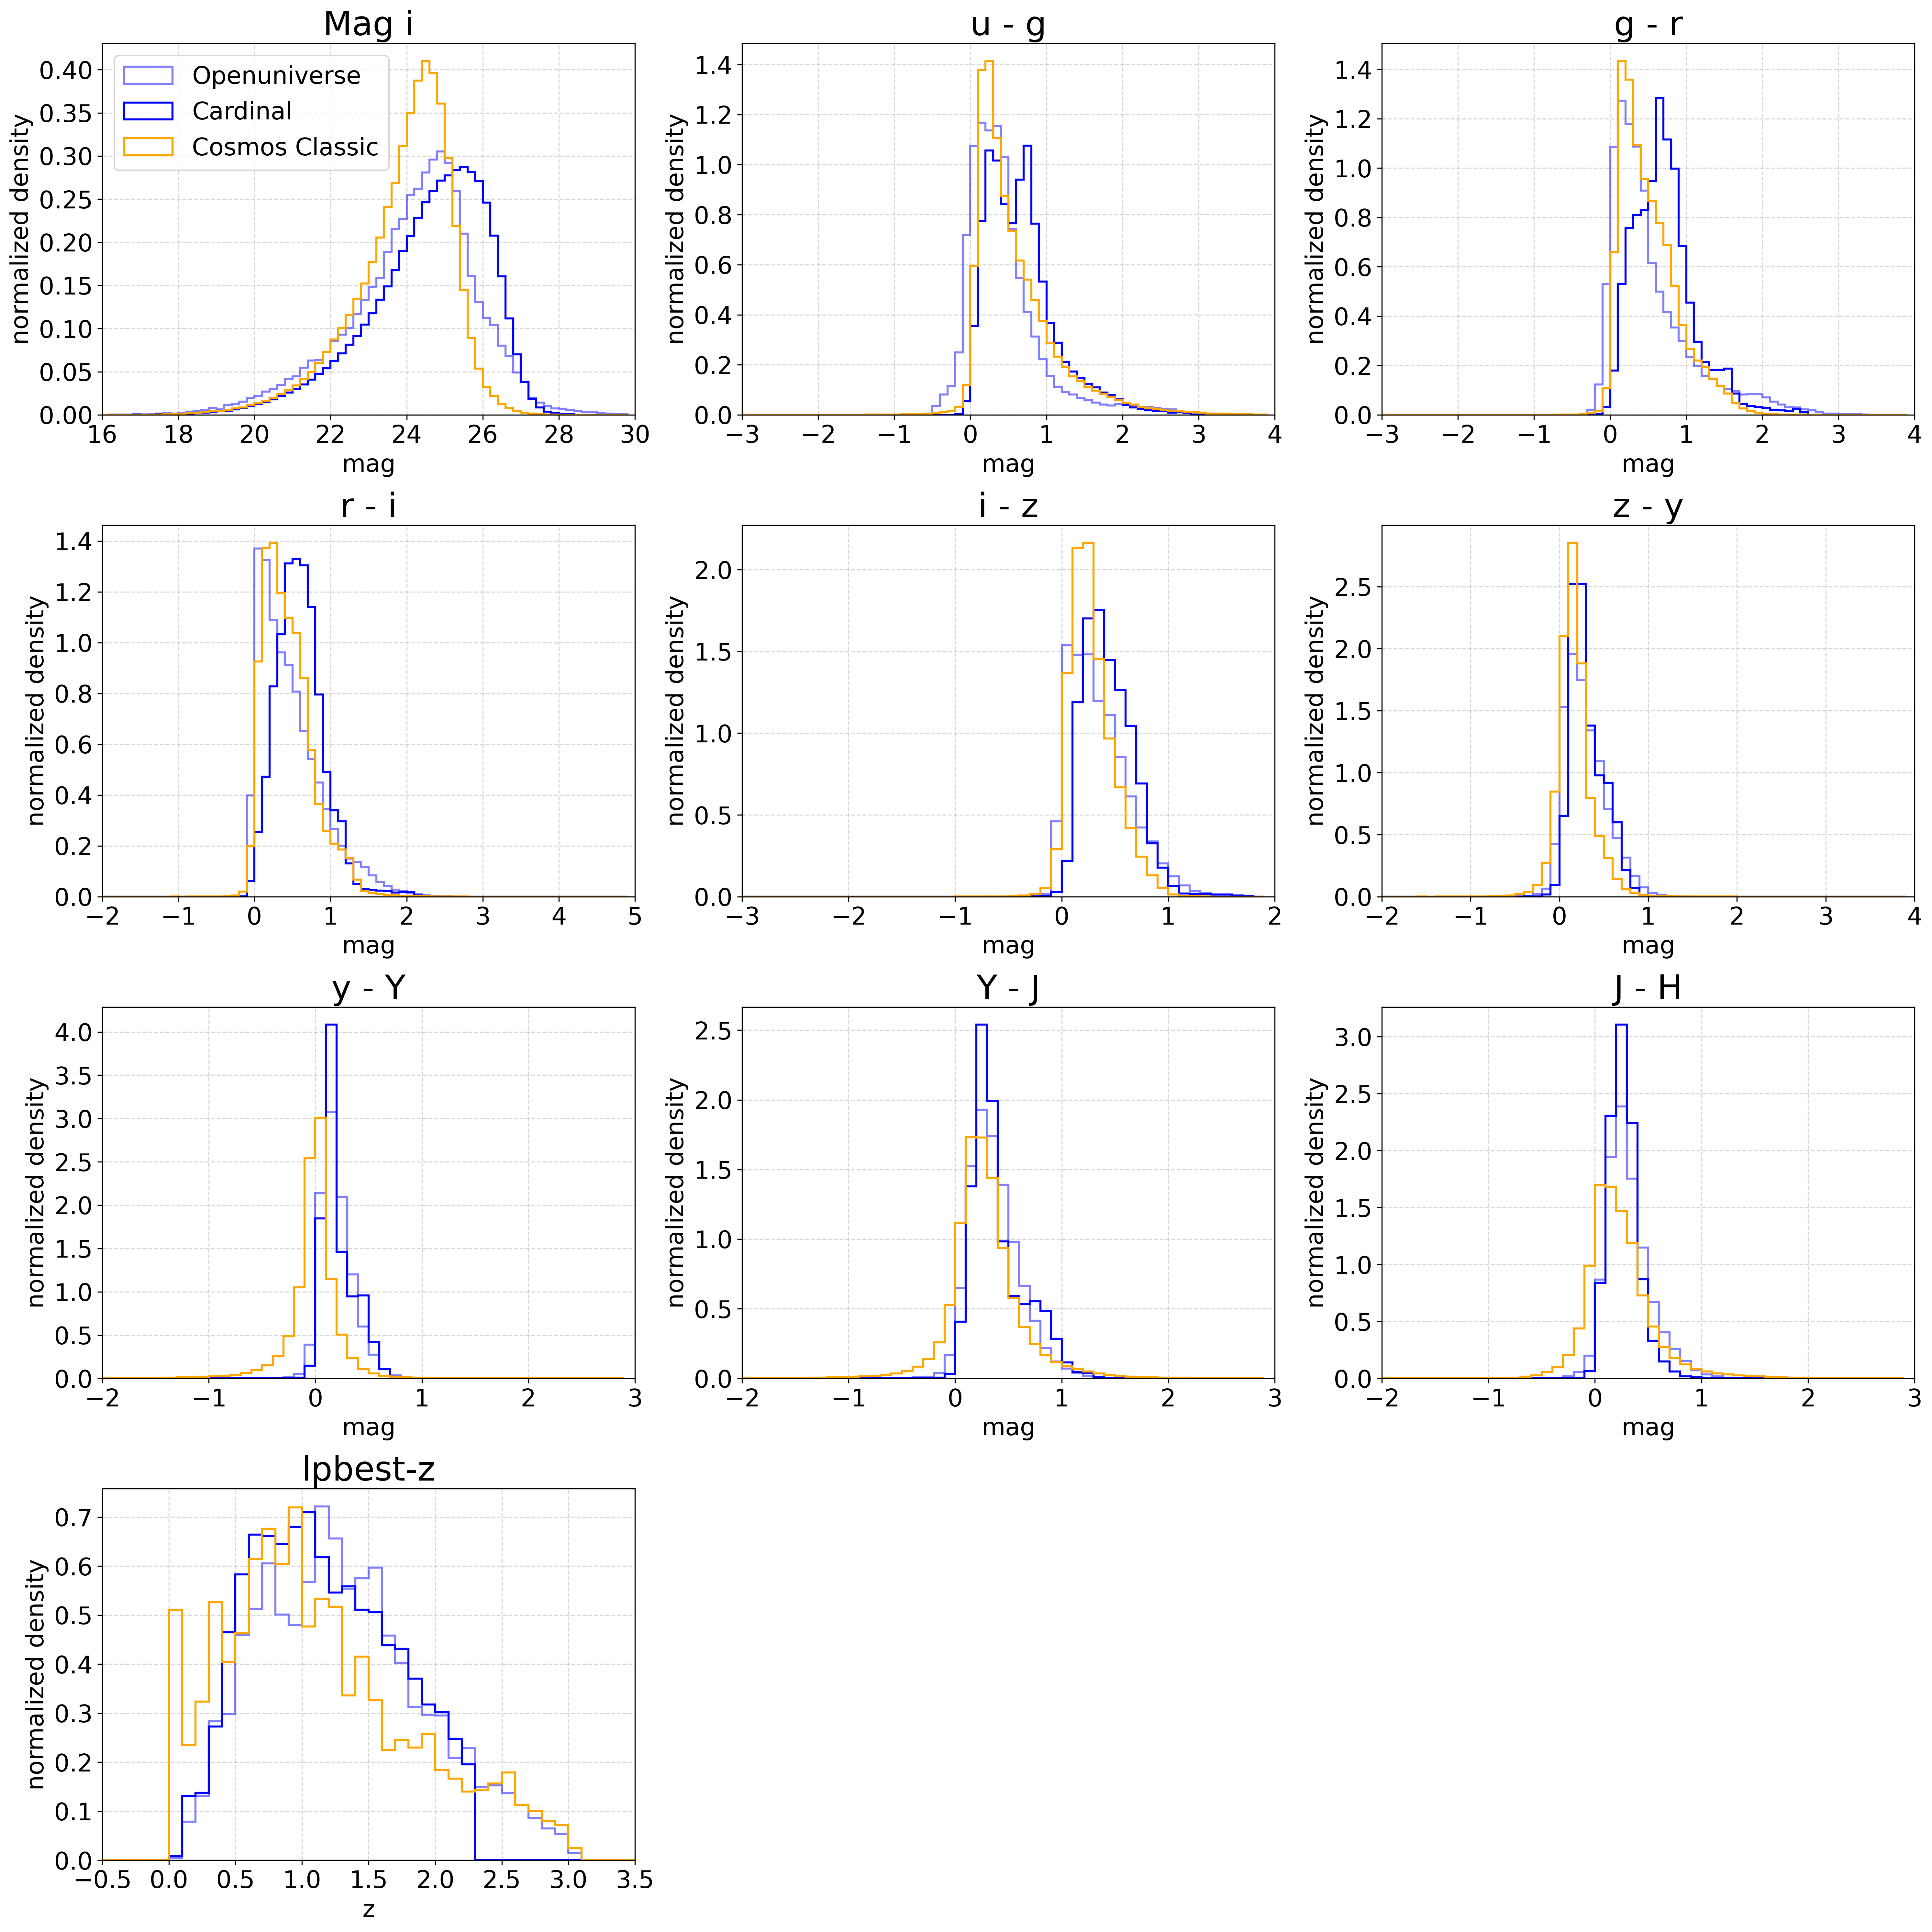

In [25]:
mag_bins = np.arange(16, 29, 0.2)
color_bins = np.arange(-2, 5, 0.1)

plot_configs = [
    {'col': 'i',     'title': 'Mag i',      'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),        'xlabel': 'mag'},
    {'col': 'u-g',   'title': 'u - g',      'bins': np.arange(-3, 4, 0.1),    'xlim': (-3, 4),         'xlabel': 'mag'},
    {'col': 'g-r',   'title': 'g - r',      'bins': np.arange(-3, 4, 0.1),    'xlim': (-3, 4),         'xlabel': 'mag'},
    {'col': 'r-i',   'title': 'r - i',      'bins': np.arange(-2, 5, 0.1),    'xlim': (-2, 5),         'xlabel': 'mag'},
    {'col': 'i-z',   'title': 'i - z',      'bins': np.arange(-3, 2, 0.1),    'xlim': (-3, 2),         'xlabel': 'mag'},
    {'col': 'z-y',   'title': 'z - y',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 4),         'xlabel': 'mag'},
    {'col': 'y-Y',   'title': 'y - Y',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),         'xlabel': 'mag'},
    {'col': 'Y-J',   'title': 'Y - J',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),         'xlabel': 'mag'},
    {'col': 'J-H',   'title': 'J - H',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),         'xlabel': 'mag'},
    {'col': 'redshift', 'title': 'lpbest-z',     'bins': np.arange(-0.5, 7, 0.1),  'xlim': (-0.5, 3.5),     'xlabel': 'z'}
]

fig = plt.figure(figsize=(20, 20), dpi = 300)


for idx, config in enumerate(plot_configs, 1):
    plt.subplot(4, 3, idx) 
    
    plt.hist(df_ou_final[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, alpha = 0.5, label='Openuniverse')
    plt.hist(df_cardinal_final[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal')
    plt.hist(df_cosmos_classic[config['col']], bins=config['bins'], histtype='step', color='orange', linewidth=1.5, density=True, label='Cosmos Classic')

    #plt.hist(df_z_classic_final[config['col']], bins=config['bins'], histtype='step', color='orange', linewidth=1.5, density=True, label='Khostovan')
    plt.title(config['title'], fontsize=25)
    plt.xlabel(config['xlabel'], fontsize=18)
    plt.ylabel("normalized density", fontsize=18)
    plt.xlim(config['xlim'])
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5) 
    
    if config['col'] == 'i':
        plt.legend(fontsize=18)

plt.tight_layout()
#plt.savefig('figs/Prematch_comparison_Classic_Cardinal_ou.png')
plt.show()

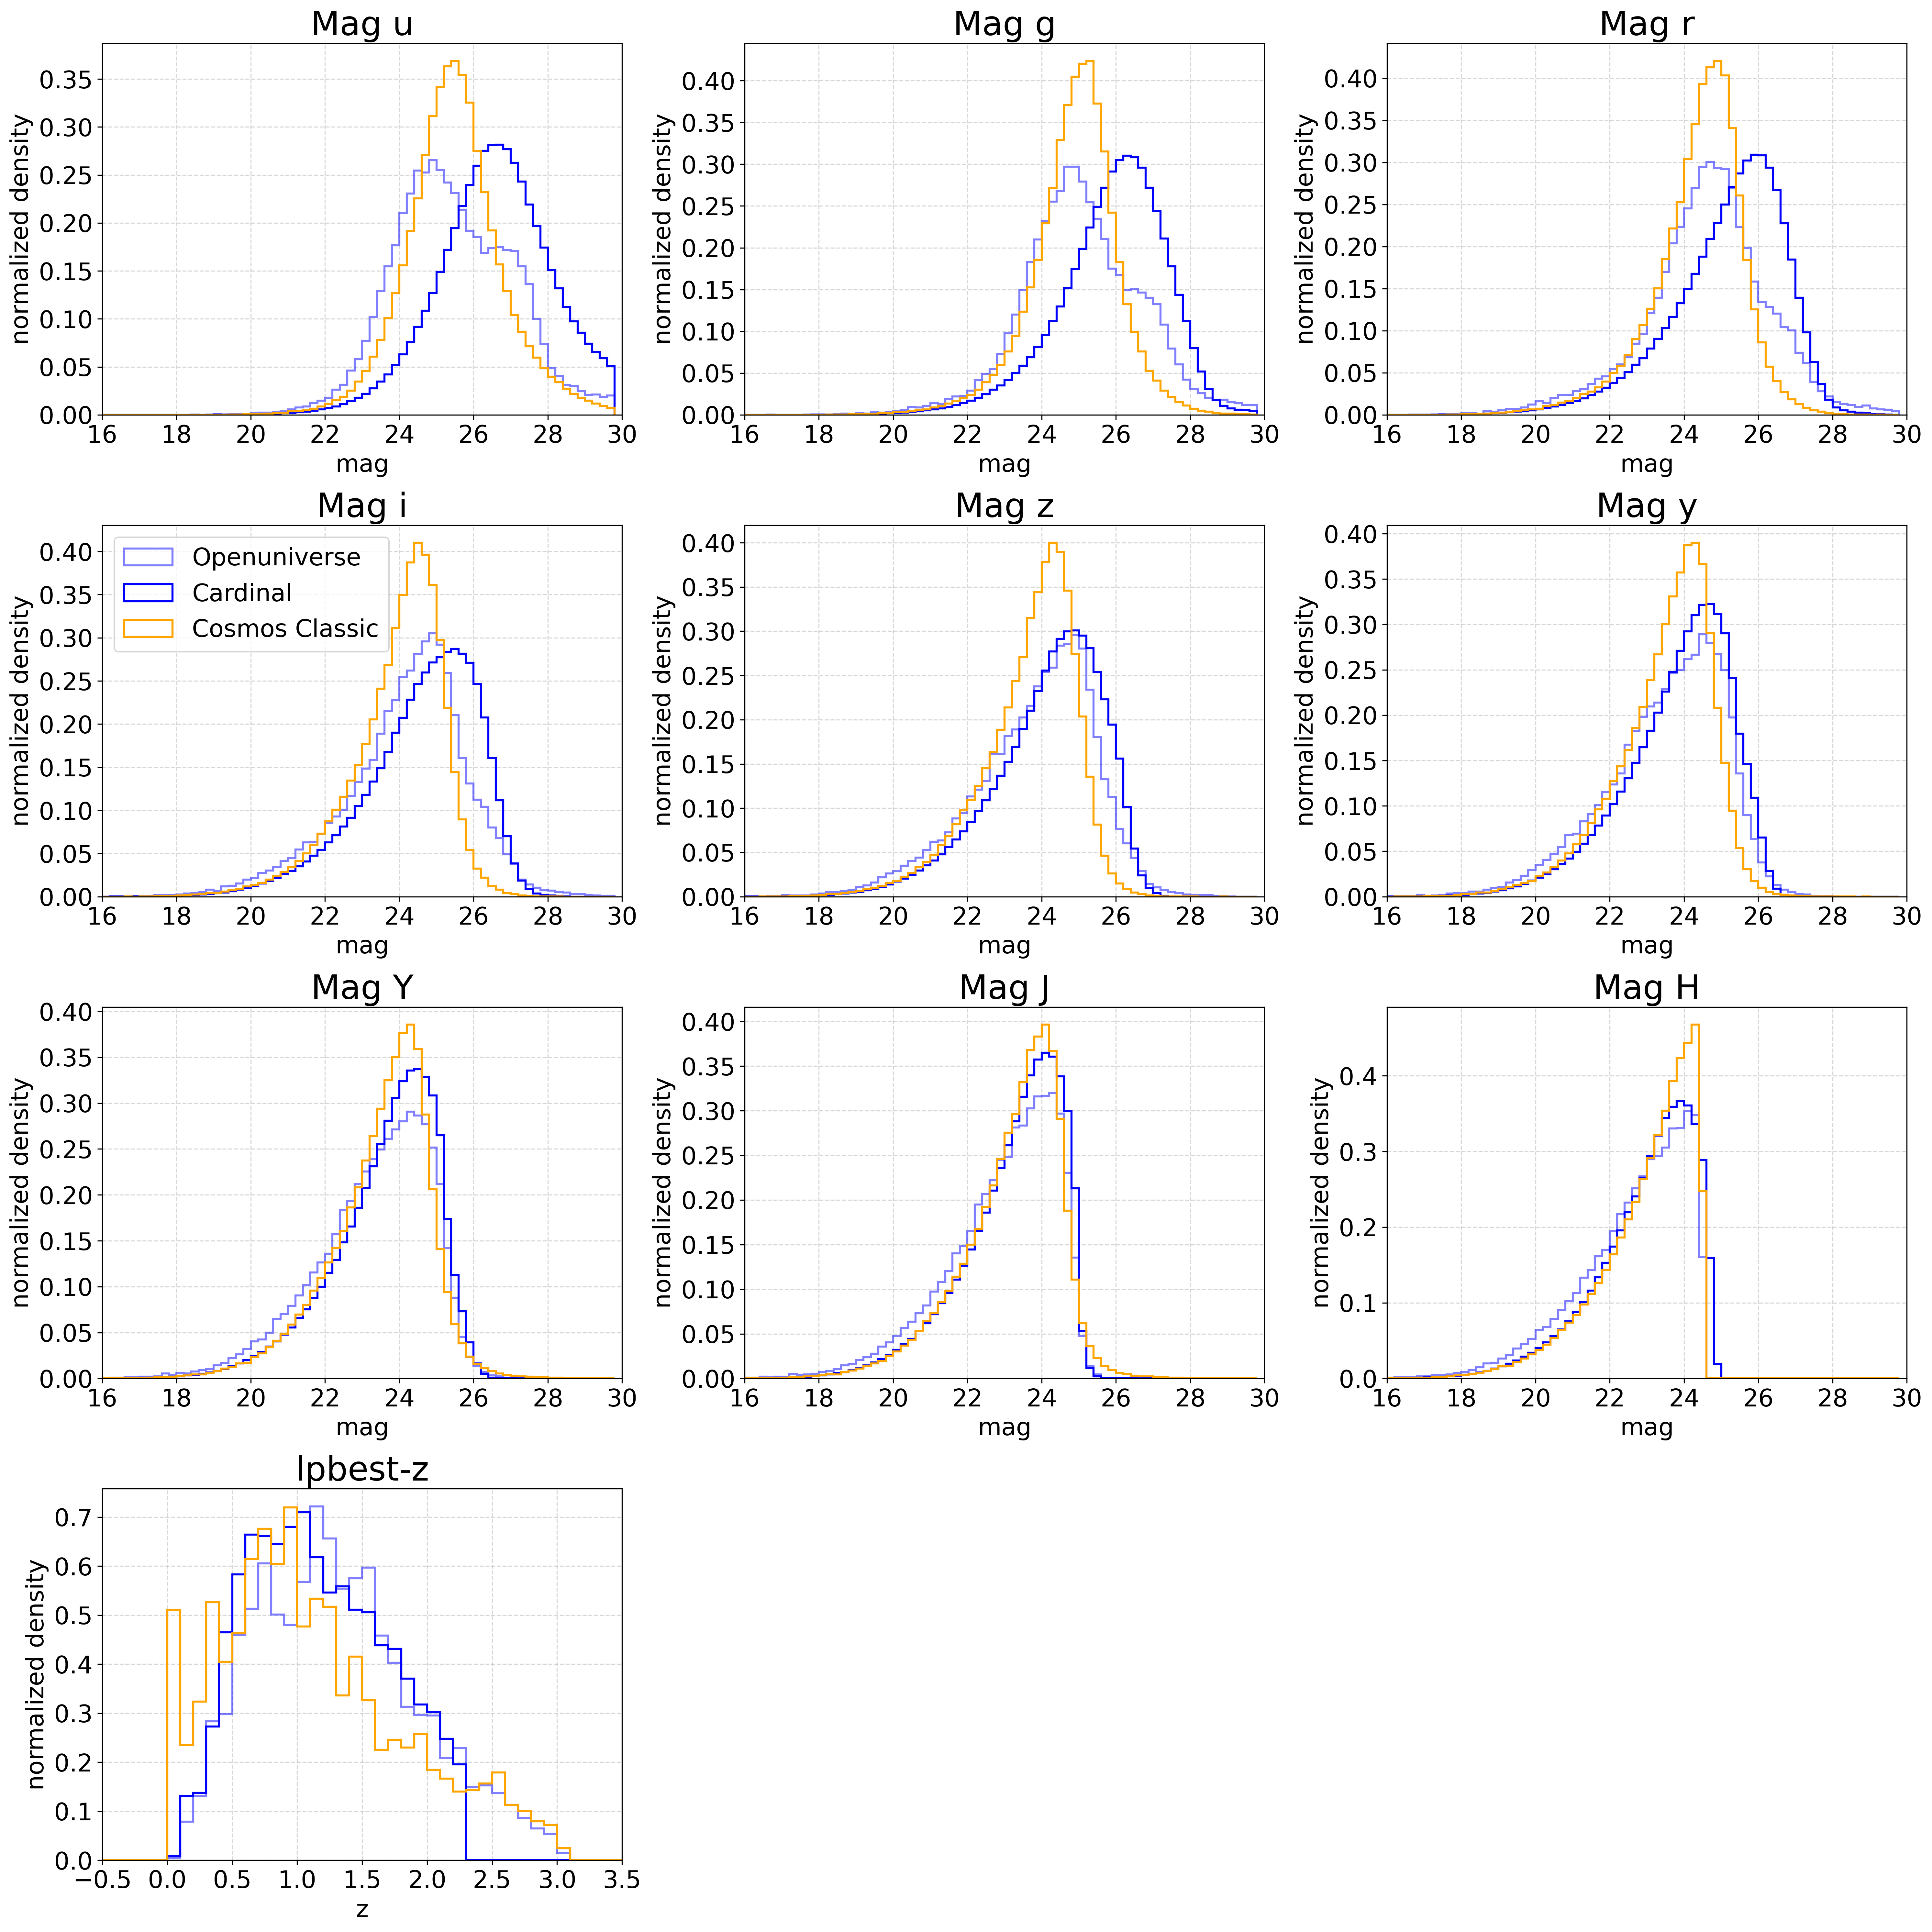

In [26]:
mag_bins = np.arange(16, 29, 0.2)
color_bins = np.arange(-2, 5, 0.1)

plot_configs = [
    {'col': 'u',     'title': 'Mag u',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'g',     'title': 'Mag g',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'r',     'title': 'Mag r',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'i',     'title': 'Mag i',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'z',     'title': 'Mag z',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'y',     'title': 'Mag y',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'Y',     'title': 'Mag Y',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'J',     'title': 'Mag J',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'H',     'title': 'Mag H',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'redshift', 'title': 'lpbest-z',     'bins': np.arange(-0.5, 7, 0.1),  'xlim': (-0.5, 3.5),     'xlabel': 'z'}
    ]

fig = plt.figure(figsize=(20, 20), dpi = 300)


for idx, config in enumerate(plot_configs, 1):
    plt.subplot(4, 3, idx) 
    
    plt.hist(df_ou_final[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, alpha = 0.5, label='Openuniverse')
    plt.hist(df_cardinal_final[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal')
    plt.hist(df_cosmos_classic[config['col']], bins=config['bins'], histtype='step', color='orange', linewidth=1.5, density=True, label='Cosmos Classic')


    plt.title(config['title'], fontsize=25)
    plt.xlabel(config['xlabel'], fontsize=18)
    plt.ylabel("normalized density", fontsize=18)
    plt.xlim(config['xlim'])
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5) 
    
    if config['col'] == 'i':
        plt.legend(fontsize=18)

plt.tight_layout()
#plt.savefig('figs/Prematch_comparison_Classic_Cardinal_ou_mag.png')
plt.show()

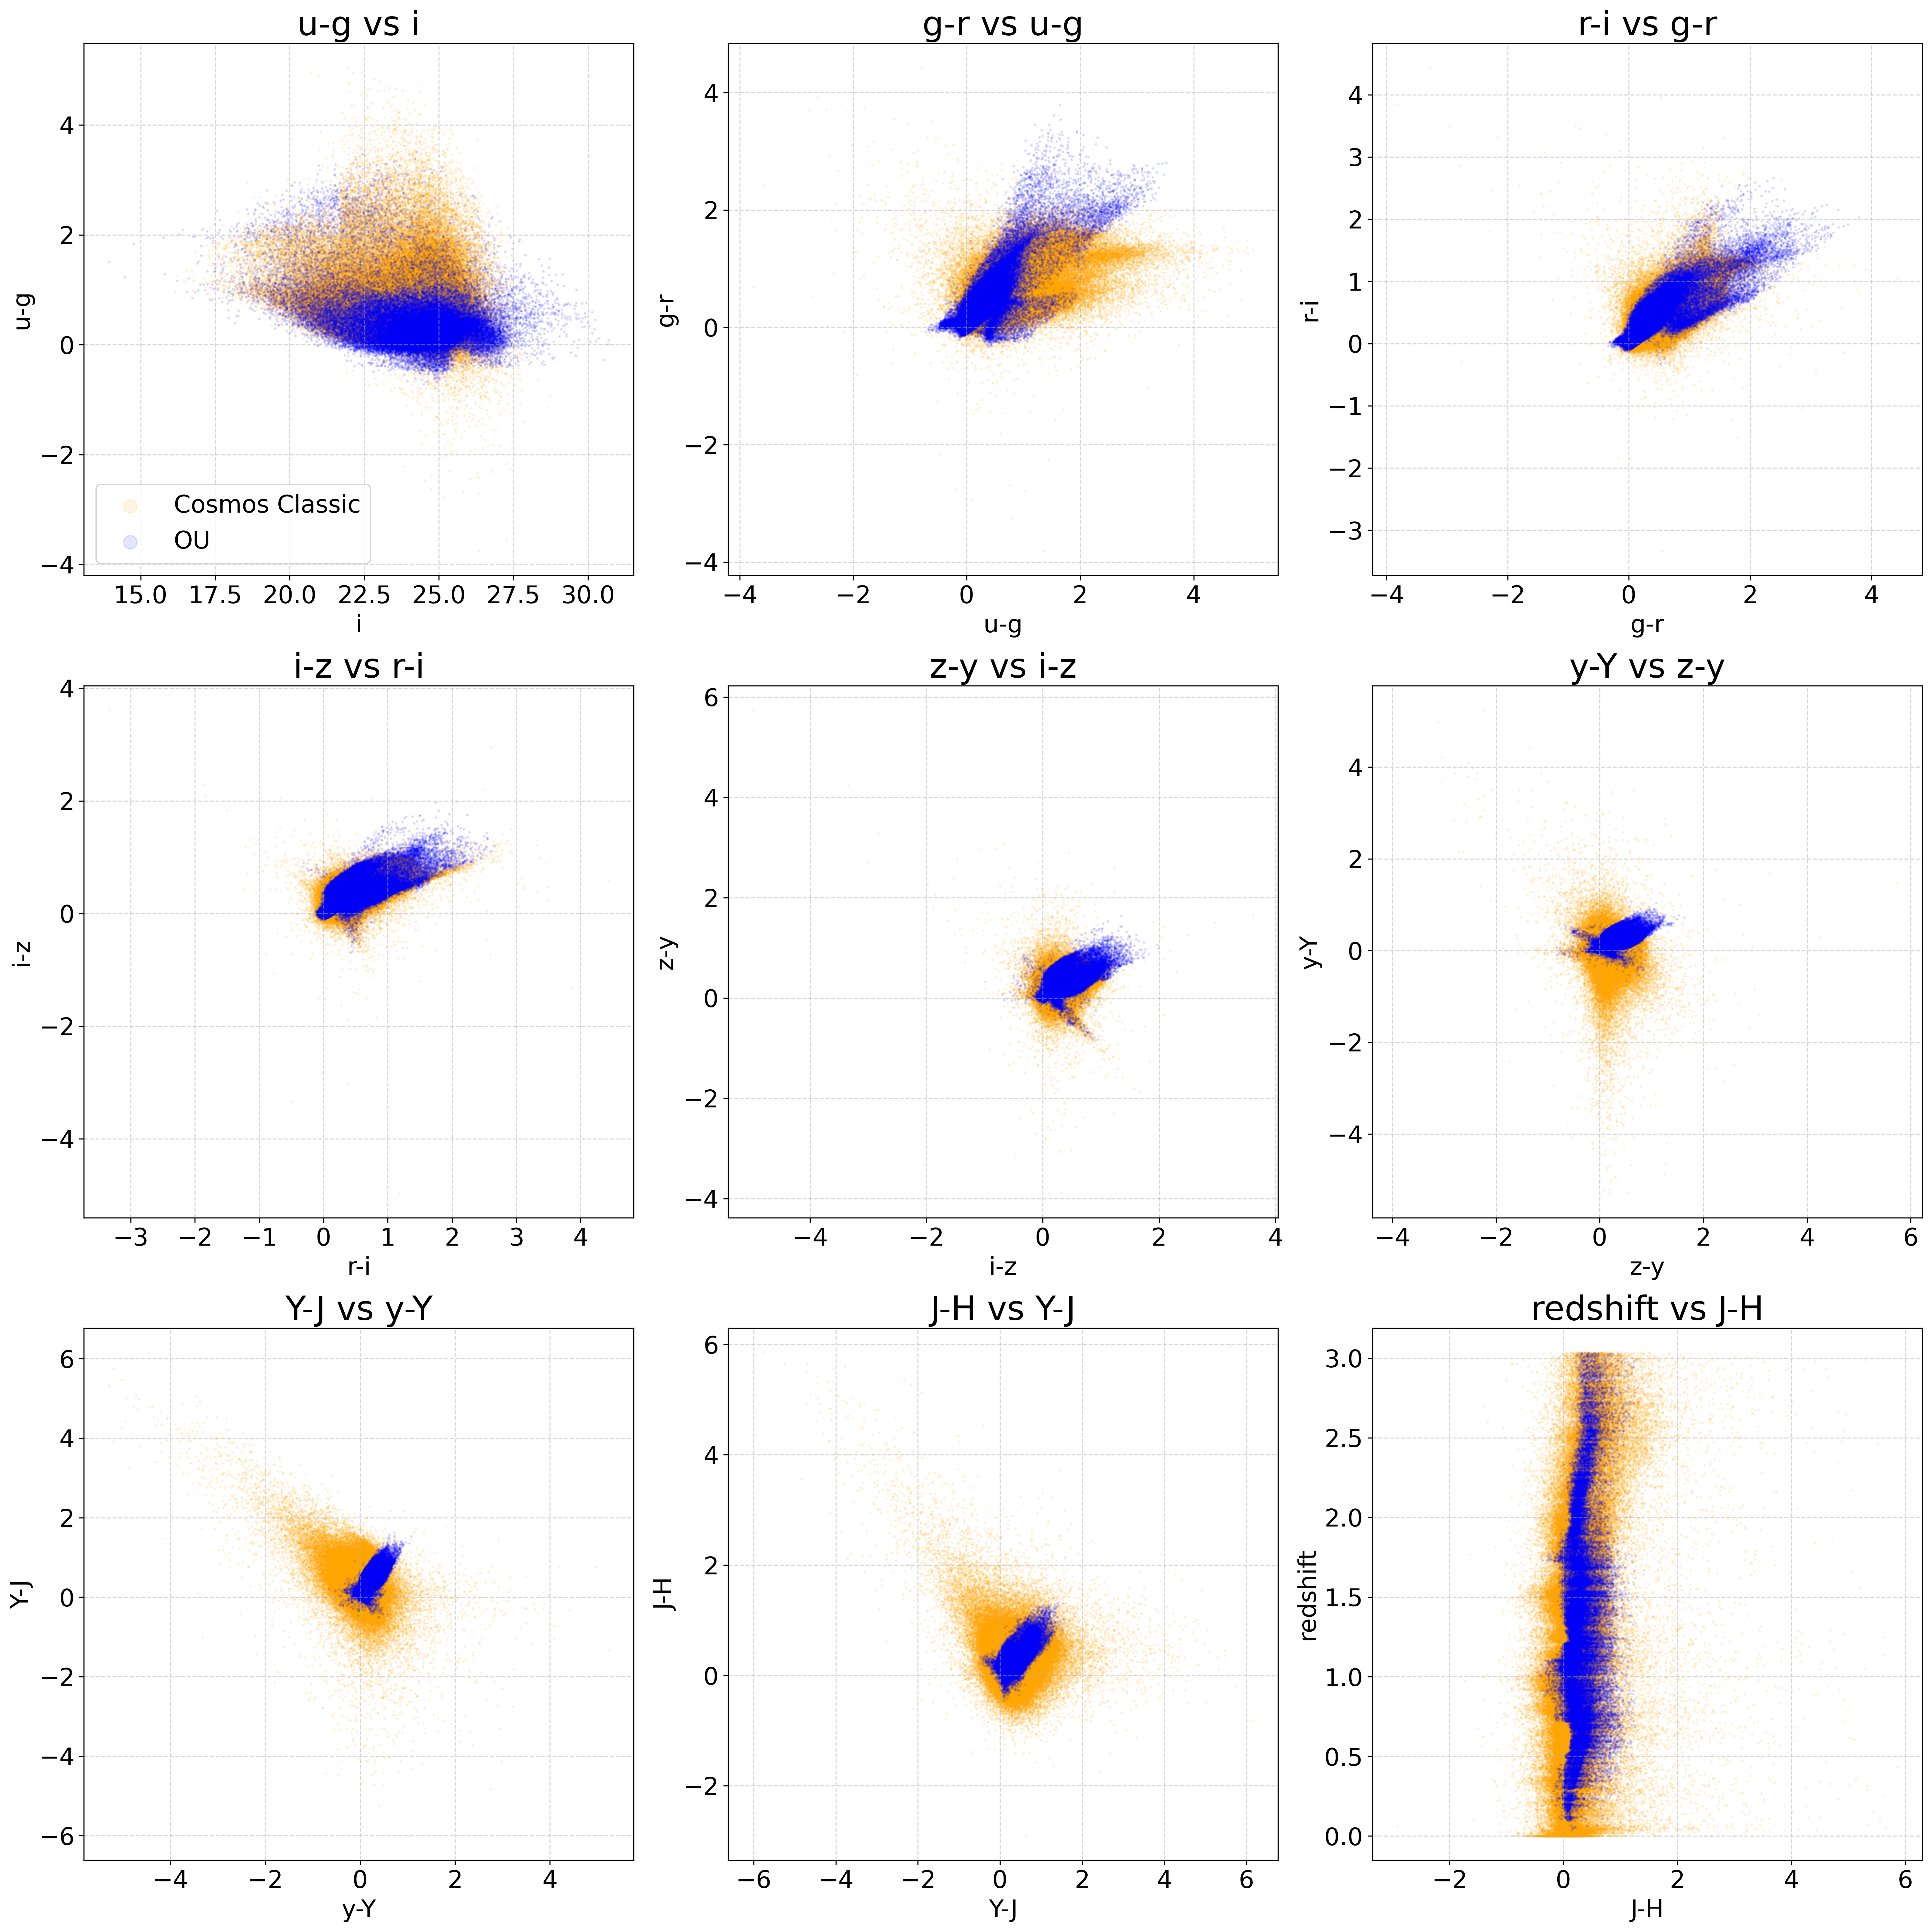

In [27]:
if mask_cosmos == 'ou':     
    cols = ['i', 'u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-Y', 'Y-J', 'J-H', 'redshift']
    
    fig = plt.figure(figsize=(20, 20), dpi=300)
    
    for idx in range(len(cols) - 1):
        col_x = cols[idx]
        col_y = cols[idx + 1]
        
        plt.subplot(3, 3, idx + 1) 
        plt.scatter(df_cosmos_classic[col_x], df_cosmos_classic[col_y], 
                    color='orange', alpha=0.1, label='Cosmos Classic', s=1)
        
        plt.scatter(df_ou_final[col_x], df_ou_final[col_y], 
                    color='blue', alpha=0.1, label='OU', s=1)
                    
        #plt.scatter(df_ou_final[col_x], df_ou_final[col_y], 
        #            color='cyan', alpha=0.2, label='Openuniverse', s=1)
                    
        
        plt.title(f"{col_y} vs {col_x}", fontsize=25)
        plt.xlabel(col_x, fontsize=18)
        plt.ylabel(col_y, fontsize=18)
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)
        plt.grid(True, linestyle='--', alpha=0.5) 
        
        if idx == 0:
            plt.legend(fontsize=18, markerscale=10)
    
    plt.tight_layout()
    plt.savefig('figs/Prematch_comparison_Classic_ou_true_scatter.png')
    plt.show()

In [ ]:
if mask_cosmos == 'ou':     
    cols = ['i', 'u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-Y', 'Y-J', 'J-H', 'redshift']
    
    fig = plt.figure(figsize=(20, 20), dpi=300)
    
    for idx in range(len(cols) - 1):
        col_x = cols[idx]
        col_y = cols[idx + 1]
        
        plt.subplot(3, 3, idx + 1) 
        plt.scatter(df_cosmos_classic[col_x], df_cosmos_classic[col_y], 
                    color='orange', alpha=0.1, label='Cosmos Classic', s=1)
        
        plt.scatter(df_ou_final[col_x], df_ou_final[col_y], 
                    color='blue', alpha=0.1, label='OU', s=1)
                    
        #plt.scatter(df_ou_final[col_x], df_ou_final[col_y], 
        #            color='cyan', alpha=0.2, label='Openuniverse', s=1)
                    
        
        plt.title(f"{col_y} vs {col_x}", fontsize=25)
        plt.xlabel(col_x, fontsize=18)
        plt.ylabel(col_y, fontsize=18)
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)
        plt.grid(True, linestyle='--', alpha=0.5) 
        
        if idx == 0:
            plt.legend(fontsize=18, markerscale=10)
    
    plt.tight_layout()
    plt.savefig('figs/Prematch_comparison_Classic_ou_true_scatter.png')
    plt.show()

In [28]:
if mask_cosmos == 'cardinal': 
    cols = ['i', 'u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-Y', 'Y-J', 'J-H', 'redshift']
    
    fig = plt.figure(figsize=(20, 20), dpi=300)
    
    for idx in range(len(cols) - 1):
        col_x = cols[idx]
        col_y = cols[idx + 1]
        
        plt.subplot(3, 3, idx + 1) 
        plt.scatter(df_cosmos_classic[col_x], df_cosmos_classic[col_y], 
                    color='orange', alpha=0.1, label='Cosmos Classic', s=1)
        
        plt.scatter(df_cardinal_final[col_x], df_cardinal_final[col_y], 
                    color='blue', alpha=0.1, label='Cardinal', s=1)
                    
        #plt.scatter(df_ou_final[col_x], df_ou_final[col_y], 
        #            color='cyan', alpha=0.2, label='Openuniverse', s=1)
                    
        
        plt.title(f"{col_y} vs {col_x}", fontsize=25)
        plt.xlabel(col_x, fontsize=18)
        plt.ylabel(col_y, fontsize=18)
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)
        plt.grid(True, linestyle='--', alpha=0.5) 
        
        if idx == 0:
            plt.legend(fontsize=18, markerscale=10)
    
    plt.tight_layout()
    plt.savefig('figs/Prematch_comparison_Classic_Cardinal_true_scatter.png')
    plt.show()

In [29]:
assert False

AssertionError: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ordered list of columns based on your original plot_configs
cols = ['i', 'u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-Y', 'Y-J', 'J-H', 'redshift']

fig = plt.figure(figsize=(20, 20), dpi=300)

for idx in range(len(cols) - 1):
    col_x = cols[idx]
    col_y = cols[idx + 1]
    
    plt.subplot(3, 3, idx + 1) 
    plt.scatter(df_cosmos_classic[col_x], df_cosmos_classic[col_y], 
                color='orange', alpha=0.1, label='Cosmos Classic', s=1)
    
    plt.scatter(df_cardinal_final[col_x], df_cardinal_final[col_y], 
                color='blue', alpha=0.1, label='Cardinal', s=1)
                
    #plt.scatter(df_ou_final[col_x], df_ou_final[col_y], 
    #            color='cyan', alpha=0.2, label='Openuniverse', s=1)
                
    
    plt.title(f"{col_y} vs {col_x}", fontsize=25)
    plt.xlabel(col_x, fontsize=18)
    plt.ylabel(col_y, fontsize=18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5) 
    
    if idx == 0:
        plt.legend(fontsize=18, markerscale=10)

plt.tight_layout()
plt.savefig('figs/Prematch_comparison_Classic_Cardinal_true_scatter.png')
plt.show()

## Plot properties vs Khostovan

In [ ]:
mag_bins = np.arange(16, 29, 0.2)
color_bins = np.arange(-2, 5, 0.1)

plot_configs = [
    {'col': 'i',     'title': 'Mag i',      'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),        'xlabel': 'mag'},
    {'col': 'u-g',   'title': 'u - g',      'bins': np.arange(-3, 4, 0.1),    'xlim': (-3, 4),         'xlabel': 'mag'},
    {'col': 'g-r',   'title': 'g - r',      'bins': np.arange(-3, 4, 0.1),    'xlim': (-3, 4),         'xlabel': 'mag'},
    {'col': 'r-i',   'title': 'r - i',      'bins': np.arange(-2, 5, 0.1),    'xlim': (-2, 5),         'xlabel': 'mag'},
    {'col': 'i-z',   'title': 'i - z',      'bins': np.arange(-3, 2, 0.1),    'xlim': (-3, 2),         'xlabel': 'mag'},
    {'col': 'z-y',   'title': 'z - y',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 4),         'xlabel': 'mag'},
    {'col': 'y-Y',   'title': 'y - Y',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),         'xlabel': 'mag'},
    {'col': 'Y-J',   'title': 'Y - J',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),         'xlabel': 'mag'},
    {'col': 'J-H',   'title': 'J - H',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),         'xlabel': 'mag'},
    {'col': 'z', 'title': 'Spec-z',     'bins': np.arange(-0.5, 7, 0.1),  'xlim': (-0.5, 3.5),     'xlabel': 'z'},
]

fig = plt.figure(figsize=(20, 20), dpi = 300)


for idx, config in enumerate(plot_configs, 1):
    plt.subplot(4, 3, idx) 
    
    plt.hist(df_ou_final[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, alpha = 0.5, label='Openuniverse')
    plt.hist(df_cardinal_final[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal')
    plt.hist(df_z_classic_final[config['col']], bins=config['bins'], histtype='step', color='orange', linewidth=1.5, density=True, label='Khostovan')
    
    plt.title(config['title'], fontsize=25)
    plt.xlabel(config['xlabel'], fontsize=18)
    plt.ylabel("normalized density", fontsize=18)
    plt.xlim(config['xlim'])
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5) 
    
    if config['col'] == 'z':
        plt.legend(fontsize=18)

plt.tight_layout()
plt.savefig('figs/Prematch_comparison_Classic_Cardinal_ou.png')
plt.show()

In [ ]:
mag_bins = np.arange(16, 29, 0.2)
color_bins = np.arange(-2, 5, 0.1)

plot_configs = [
    {'col': 'u',     'title': 'Mag u',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'g',     'title': 'Mag g',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'r',     'title': 'Mag r',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'i',     'title': 'Mag i',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'z',     'title': 'Mag z',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'y',     'title': 'Mag y',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'Y',     'title': 'Mag Y',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'J',     'title': 'Mag J',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'H',     'title': 'Mag H',  'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),      'xlabel': 'mag'},
    {'col': 'z', 'title': 'Spec-z', 'bins': np.arange(-0.5, 7, 0.1),  'xlim': (-0.5, 3.5),   'xlabel': 'z'},
]

fig = plt.figure(figsize=(20, 20), dpi = 300)


for idx, config in enumerate(plot_configs, 1):
    plt.subplot(4, 3, idx) 
    
    plt.hist(df_ou_final[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, alpha = 0.5, label='Openuniverse')
    plt.hist(df_cardinal_final[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal')
 
    plt.hist(df_z_classic_final[config['col']], bins=config['bins'], histtype='step', color='orange', linewidth=1.5, density=True, label='Khostovan')
    plt.title(config['title'], fontsize=25)
    plt.xlabel(config['xlabel'], fontsize=18)
    plt.ylabel("normalized density", fontsize=18)
    plt.xlim(config['xlim'])
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5) 
    
    if config['col'] == 'z':
        plt.legend(fontsize=18)

plt.tight_layout()
plt.savefig('figs/Prematch_comparison_Classic_Cardinal_ou_mag.png')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ordered list of columns based on your original plot_configs
cols = ['i', 'u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-Y', 'Y-J', 'J-H', 'z']

fig = plt.figure(figsize=(20, 20), dpi=300)

for idx in range(len(cols) - 1):
    col_x = cols[idx]
    col_y = cols[idx + 1]
    
    plt.subplot(3, 3, idx + 1) 
    
    plt.scatter(df_cardinal_final[col_x], df_cardinal_final[col_y], 
                color='blue', alpha=0.2, label='Cardinal', s=1)
                
    plt.scatter(df_ou_final[col_x], df_ou_final[col_y], 
                color='cyan', alpha=0.2, label='Openuniverse', s=1)
                
    plt.scatter(df_z_classic_final[col_x], df_z_classic_final[col_y], 
                color='orange', alpha=0.2, label='Khostovan', s=1)
    
    plt.title(f"{col_y} vs {col_x}", fontsize=25)
    plt.xlabel(col_x, fontsize=18)
    plt.ylabel(col_y, fontsize=18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5) 
    
    if idx == 0:
        plt.legend(fontsize=18, markerscale=10)

plt.tight_layout()
plt.savefig('figs/Prematch_comparison_Classic_Cardinal_ou_scatter.png')
plt.show()

In [ ]:
def plot_2d_contours(x, y, ax, color, bins=100, smoothing=1.5):
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean, y_clean = x[mask], y[mask]
    
    if len(x_clean) == 0:
        return 
        
    H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=bins)
    
    if smoothing > 0:
        H = gaussian_filter(H, sigma=smoothing)
        
    H_flat = H.flatten()
    H_flat_sorted = np.sort(H_flat)[::-1] 
    
    cum_sum = np.cumsum(H_flat_sorted)
    cum_sum_norm = cum_sum / cum_sum[-1] 
    
    level_1sigma = H_flat_sorted[np.searchsorted(cum_sum_norm, 0.6827)]
    level_2sigma = H_flat_sorted[np.searchsorted(cum_sum_norm, 0.9545)]
    
    X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
    
    ax.contour(X, Y, H.T, levels=[level_2sigma, level_1sigma], 
               colors=color, linewidths=[1.5, 2.5], linestyles=['--', '-'], alpha=0.8)


cols = ['i', 'u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-Y', 'Y-J', 'J-H', 'z']

fig = plt.figure(figsize=(20, 20), dpi=300)

for idx in range(len(cols) - 1):
    col_x = cols[idx]
    col_y = cols[idx + 1]
    
    ax = plt.subplot(3, 3, idx + 1) 
    
    plot_2d_contours(df_cardinal_final[col_x], df_cardinal_final[col_y], 
                     ax, color='blue')
                     
    plot_2d_contours(df_ou_final[col_x], df_ou_final[col_y], 
                     ax, color='cyan')
                     
    plot_2d_contours(df_z_classic_final[col_x], df_z_classic_final[col_y], 
                     ax, color='orange')
    
    ax.set_title(f"{col_y} vs {col_x}", fontsize=25)
    ax.set_xlabel(col_x, fontsize=18)
    ax.set_ylabel(col_y, fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.grid(True, linestyle='--', alpha=0.5) 

    if col_x == 'i':
        ax.set_xlim(17, 30) 
    else:
        ax.set_xlim(-3, 3) 

    if col_y == 'z':
        ax.set_ylim(-0.5, 3) 
    else:
        ax.set_ylim(-3, 3) 
        
    if idx == 0:
        custom_lines = [
            Line2D([0], [0], color='blue', lw=2, label='Cardinal sim full'),
            Line2D([0], [0], color='cyan', lw=2, label='Cardinal sim reduced'),
            Line2D([0], [0], color='orange', lw=2, label='Khostovan'),
            Line2D([0], [0], color='gray', lw=2.5, linestyle='-', label=r'1$\sigma$ (68%)'),
            Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label=r'2$\sigma$ (95%)')
        ]
        ax.legend(handles=custom_lines, fontsize=15, loc='best')

plt.tight_layout()
plt.savefig('figs/Prematch_comparison_Classic_Cardinal_ou_contours.png')
plt.show()